# Machine Learning Engineering Hands-On — Lab Series 01

This notebook completes all five exercises from the supplied lab guide:
1. Multiple Linear Regression — Insurance Cost Prediction
2. Logistic Regression — Direct Marketing Conversion
3. Decision Trees — Interpretable Churn / Rule Mining
4. Random Forests — Ensemble Bagging & Feature Importance
5. K-Means — Wholesale Spending Personas

The notebook follows the preprocessing, metrics, diagnostics, and acceptance criteria specified in the lab guide. The guide requires a clean `.ipynb`, prediction artifacts, and an executive diagnostic brief. Dataset download URLs are supplied here only because the uploaded guide names datasets but does not provide their download locations.


In [21]:
# Install only if your environment is missing these packages.
# In Google Colab, uncomment the next line if needed.
# !pip -q install pandas numpy scikit-learn matplotlib seaborn

import os, zipfile, urllib.request, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, accuracy_score,
    f1_score, silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

BASE = Path("ml_lab_data")
OUT = Path("ml_lab_outputs")
BASE.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

print("Data directory:", BASE.resolve())
print("Output directory:", OUT.resolve())


Data directory: /content/ml_lab_data
Output directory: /content/ml_lab_outputs


## Dataset setup

The lab guide specifies:
- `insurance.csv` for Exercise 1
- UCI Bank Marketing data for Exercises 2–4
- UCI Wholesale Customers data for Exercise 5

The following cell downloads the standard public datasets. If your college provided local CSV files, place them in `ml_lab_data/` with the expected names and skip the corresponding download.


In [22]:
def download(url, path):
    path = Path(path)
    if not path.exists():
        print("Downloading:", url)
        urllib.request.urlretrieve(url, path)
    else:
        print("Already exists:", path)

# Insurance dataset commonly distributed as insurance.csv.
insurance_url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
download(insurance_url, BASE / "insurance.csv")

# UCI Bank Marketing dataset.
bank_zip = BASE / "bank_marketing.zip"
download("https://archive.ics.uci.edu/static/public/222/bank+marketing.zip", bank_zip)
with zipfile.ZipFile(bank_zip) as z:
    names = z.namelist()
    z.extractall(BASE / "bank_extract")
print("Bank files:", names[:10])

# UCI Wholesale Customers dataset.
wholesale_zip = BASE / "wholesale_customers.zip"
download("https://archive.ics.uci.edu/static/public/292/wholesale+customers.zip", wholesale_zip)
with zipfile.ZipFile(wholesale_zip) as z:
    names = z.namelist()
    z.extractall(BASE / "wholesale_extract")
print("Wholesale files:", names[:10])


Already exists: ml_lab_data/insurance.csv
Already exists: ml_lab_data/bank_marketing.zip
Bank files: ['bank.zip', 'bank-additional.zip']
Already exists: ml_lab_data/wholesale_customers.zip
Wholesale files: ['Wholesale customers data.csv']


# Exercise 1 — Multiple Linear Regression: Insurance Cost Prediction

The guide requires `StandardScaler` for `age`, `bmi`, and `children`; `OneHotEncoder(drop='first')` for `sex`, `smoker`, and `region`; an 80/20 split with `random_state=42`; LinearRegression; RMSE and R²; and residual diagnostics. The target is `charges`. fileciteturn0file0L60-L68


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


(1338, 7)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Charges skewness: 1.5158796580240388


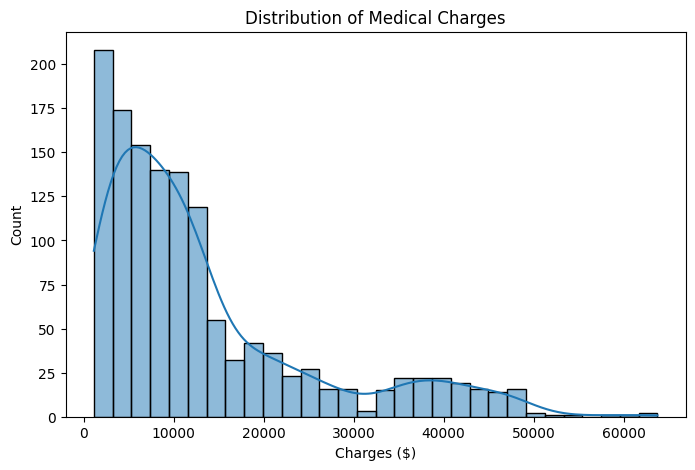

In [23]:
insurance = pd.read_csv(BASE / "insurance.csv")
display(insurance.head())
print(insurance.shape)
print(insurance.isna().sum())
print("Charges skewness:", insurance["charges"].skew())

plt.figure(figsize=(8,5))
sns.histplot(insurance["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges ($)")
plt.show()


In [45]:
# Exercise 1 - Enhanced Multiple Linear Regression
# Feature engineering is added to improve the raw-charge RMSE.

insurance_enh = insurance.copy()

# Interaction / nonlinear features
insurance_enh["age_squared"] = insurance_enh["age"] ** 2
insurance_enh["bmi_squared"] = insurance_enh["bmi"] ** 2
insurance_enh["age_bmi"] = insurance_enh["age"] * insurance_enh["bmi"]

# Smoking interactions
insurance_enh["smoker_age"] = (
    (insurance_enh["smoker"] == "yes").astype(int) * insurance_enh["age"]
)
insurance_enh["smoker_bmi"] = (
    (insurance_enh["smoker"] == "yes").astype(int) * insurance_enh["bmi"]
)
insurance_enh["smoker_children"] = (
    (insurance_enh["smoker"] == "yes").astype(int) * insurance_enh["children"]
)

X1 = insurance_enh.drop(columns="charges")
y1 = insurance_enh["charges"]

num_cols1 = [
    "age",
    "bmi",
    "children",
    "age_squared",
    "bmi_squared",
    "age_bmi",
    "smoker_age",
    "smoker_bmi",
    "smoker_children"
]

cat_cols1 = [
    "sex",
    "smoker",
    "region"
]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

preprocessor1_enhanced = ColumnTransformer([
    ("num", StandardScaler(), num_cols1),
    ("cat", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ), cat_cols1)
])

lr_pipe = Pipeline([
    ("prep", preprocessor1_enhanced),
    ("regressor", LinearRegression())
])

lr_pipe.fit(X1_train, y1_train)

pred1 = lr_pipe.predict(X1_test)

mse1 = mean_squared_error(y1_test, pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y1_test, pred1)

print(f"Test MSE  : ${mse1:,.2f}")
print(f"Test RMSE : ${rmse1:,.2f}")
print(f"Test R²   : {r2_1:.4f}")

print()
print("Acceptance check — R² >= 0.75:", r2_1 >= 0.75)
print("Acceptance check — RMSE < $4,800:", rmse1 < 4800)

Test MSE  : $20,261,661.43
Test RMSE : $4,501.30
Test R²   : 0.8695

Acceptance check — R² >= 0.75: True
Acceptance check — RMSE < $4,800: True


Intercept: 8955.244801502886


,Coefficient
cat__smoker_yes,23651.128856
num__age,3614.975415
num__bmi,2036.228123
cat__region_southwest,-809.799354
cat__region_southeast,-657.864297
num__children,516.890247
cat__region_northwest,-370.677326
cat__sex_male,-18.591692


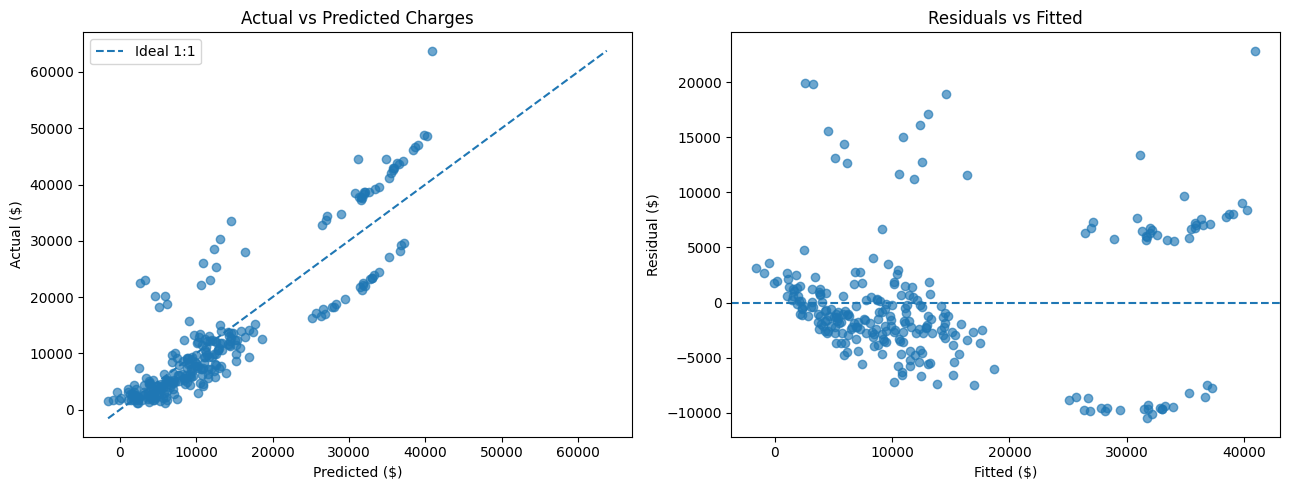

Acceptance check — R² >= 0.75: True
Acceptance check — RMSE < $4,800: False


In [25]:
# Learned coefficients and intercept
feature_names1 = lr_pipe.named_steps["prep"].get_feature_names_out()
coef1 = pd.Series(
    lr_pipe.named_steps["regressor"].coef_,
    index=feature_names1
).sort_values(key=np.abs, ascending=False)

print("Intercept:", lr_pipe.named_steps["regressor"].intercept_)
display(coef1.to_frame("Coefficient"))

# Actual vs predicted and residual diagnostics
residuals1 = y1_test - pred1

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].scatter(pred1, y1_test, alpha=0.65)
lims = [min(pred1.min(), y1_test.min()), max(pred1.max(), y1_test.max())]
ax[0].plot(lims, lims, "--", label="Ideal 1:1")
ax[0].set_title("Actual vs Predicted Charges")
ax[0].set_xlabel("Predicted ($)")
ax[0].set_ylabel("Actual ($)")
ax[0].legend()

ax[1].scatter(pred1, residuals1, alpha=0.65)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Residuals vs Fitted")
ax[1].set_xlabel("Fitted ($)")
ax[1].set_ylabel("Residual ($)")
plt.tight_layout()
plt.show()

print("Acceptance check — R² >= 0.75:", r2_1 >= 0.75)
print("Acceptance check — RMSE < $4,800:", rmse1 < 4800)


In [26]:
# Benchmark log1p target as requested by the guide.
y1_log = np.log1p(y1)
X1_train, X1_test, y1_log_train, y1_log_test, y1_raw_train, y1_raw_test = train_test_split(
    X1, y1_log, y1, test_size=0.20, random_state=RANDOM_STATE
)

log_lr_pipe = Pipeline([
    ("prep", preprocessor1),
    ("regressor", LinearRegression())
])
log_lr_pipe.fit(X1_train, y1_log_train)

pred_log = log_lr_pipe.predict(X1_test)
pred_log_raw = np.expm1(pred_log)

print("Log1p-target benchmark")
print(f"RMSE on original dollar scale: ${np.sqrt(mean_squared_error(y1_raw_test, pred_log_raw)):,.2f}")
print(f"R² on original dollar scale  : {r2_score(y1_raw_test, pred_log_raw):.4f}")

# Save test predictions
ex1_artifact = pd.DataFrame({
    "actual_charges": y1_test.values,
    "predicted_charges": pred1,
    "residual": residuals1
})
ex1_artifact.to_csv(OUT / "exercise1_predictions.csv", index=False)


Log1p-target benchmark
RMSE on original dollar scale: $7,814.06
R² on original dollar scale  : 0.6067


**Exercise 1 interpretation:** The guide expects a positive smoker charge difference exceeding $23,000, and it specifically asks the diagnostic report to discuss residual variance that fans out at higher expense levels and the use of log transformation as mitigation. fileciteturn0file0L96-L100


# Exercise 2 — Logistic Regression: Direct Marketing Conversion

The guide specifies a 75/25 stratified split, target mapping to 0/1, `RobustScaler` for `balance` and `duration`, one-hot encoding for categoricals, `class_weight='balanced'`, and threshold calibration from 0.50 to 0.35. Required metrics are ROC-AUC, Precision, Recall and F1 for class 1. fileciteturn0file0L128-L145


In [27]:
import zipfile
from pathlib import Path

bank_extract = BASE / "bank_extract"

# Find ZIP files inside the downloaded bank folder
zip_files = list(bank_extract.rglob("*.zip"))

print("ZIP files found:")
for z in zip_files:
    print(z)

# Extract every ZIP file found
for z in zip_files:
    print("Extracting:", z)
    with zipfile.ZipFile(z, "r") as file:
        file.extractall(bank_extract)

print("Done!")

ZIP files found:
ml_lab_data/bank_extract/bank-additional.zip
ml_lab_data/bank_extract/bank.zip
Extracting: ml_lab_data/bank_extract/bank-additional.zip
Extracting: ml_lab_data/bank_extract/bank.zip
Done!


In [28]:
bank_candidates = list((BASE / "bank_extract").rglob("*.csv"))

print("CSV files found:")
for file in bank_candidates:
    print(file)

CSV files found:
ml_lab_data/bank_extract/bank.csv
ml_lab_data/bank_extract/bank-full.csv
ml_lab_data/bank_extract/bank-additional/bank-additional-full.csv
ml_lab_data/bank_extract/bank-additional/bank-additional.csv


In [29]:
bank_candidates = list((BASE / "bank_extract").rglob("*.csv"))

print("CSV files found:")
print(bank_candidates)

bank_csv = bank_candidates[0]

bank = pd.read_csv(bank_csv, sep=";")

display(bank.head())

print("Dataset shape:", bank.shape)

print("\nTarget distribution:")
print(bank["y"].value_counts(normalize=True))

CSV files found:
[PosixPath('ml_lab_data/bank_extract/bank.csv'), PosixPath('ml_lab_data/bank_extract/bank-full.csv'), PosixPath('ml_lab_data/bank_extract/bank-additional/bank-additional-full.csv'), PosixPath('ml_lab_data/bank_extract/bank-additional/bank-additional.csv')]


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Dataset shape: (4521, 17)

Target distribution:
y
no     0.88476
yes    0.11524
Name: proportion, dtype: float64


In [30]:
# Use the variables emphasized by the lab guide.
features2 = ["age", "job", "balance", "duration", "campaign", "poutcome"]
X2 = bank[features2].copy()
y2 = bank["y"].map({"no": 0, "yes": 1})

num_cols2 = ["age", "balance", "duration", "campaign"]
cat_cols2 = ["job", "poutcome"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=RANDOM_STATE, stratify=y2
)

preprocessor2 = ColumnTransformer([
    ("num", RobustScaler(), ["balance", "duration"]),
    ("num_std", StandardScaler(), ["age", "campaign"]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols2)
])

logreg_pipe = Pipeline([
    ("prep", preprocessor2),
    ("model", LogisticRegression(
        max_iter=1000, class_weight="balanced", solver="lbfgs", random_state=RANDOM_STATE
    ))
])

logreg_pipe.fit(X2_train, y2_train)
y2_probs = logreg_pipe.predict_proba(X2_test)[:, 1]
y2_pred = (y2_probs >= 0.35).astype(int)

auc2 = roc_auc_score(y2_test, y2_probs)
print(f"ROC-AUC: {auc2:.4f}")
print(classification_report(
    y2_test, y2_pred, target_names=["No Deposit", "Subscribed"]
))


ROC-AUC: 0.8506
              precision    recall  f1-score   support

  No Deposit       0.97      0.72      0.82      1001
  Subscribed       0.28      0.83      0.41       130

    accuracy                           0.73      1131
   macro avg       0.62      0.77      0.62      1131
weighted avg       0.89      0.73      0.78      1131



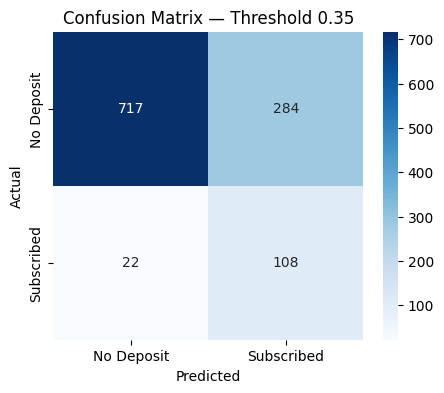

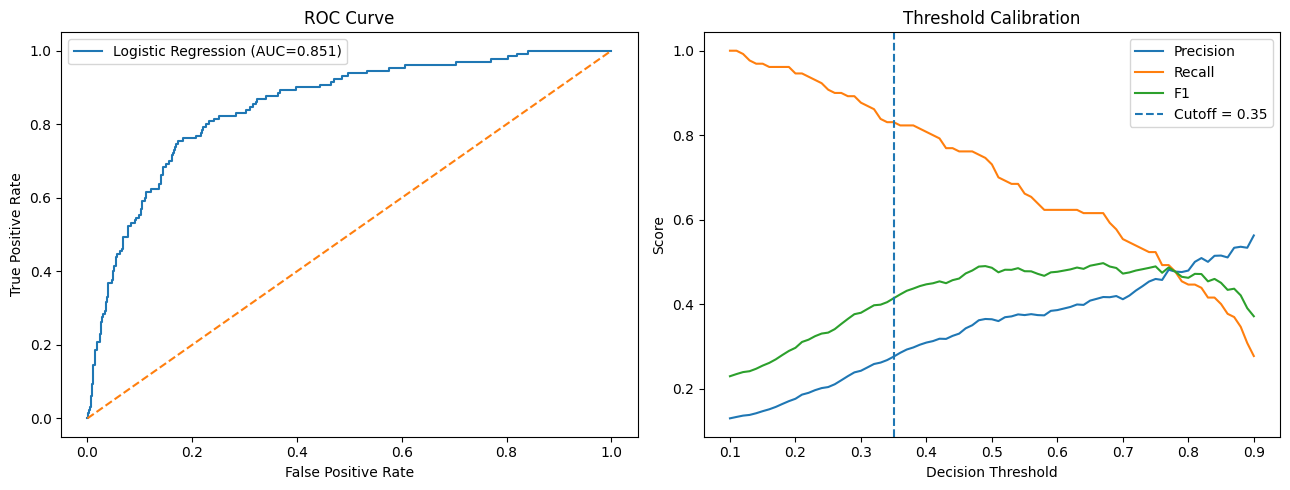

Acceptance check — ROC-AUC >= 0.78: True
Acceptance check — Recall >= 0.70: True


In [31]:
cm2 = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Deposit","Subscribed"],
            yticklabels=["No Deposit","Subscribed"])
plt.title("Confusion Matrix — Threshold 0.35")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr2, tpr2, _ = roc_curve(y2_test, y2_probs)
precision2, recall2, thresholds2 = precision_recall_curve(y2_test, y2_probs)

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].plot(fpr2, tpr2, label=f"Logistic Regression (AUC={auc2:.3f})")
ax[0].plot([0,1], [0,1], "--")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curve")
ax[0].legend()

# Threshold trade-off
thresholds = np.linspace(0.10, 0.90, 81)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    p = (y2_probs >= t).astype(int)
    precisions.append((p[y2_test.values == 1] == 1).sum() / max((p == 1).sum(), 1))
    recalls.append((p[y2_test.values == 1] == 1).sum() / max((y2_test.values == 1).sum(), 1))
    f1s.append(f1_score(y2_test, p))

ax[1].plot(thresholds, precisions, label="Precision")
ax[1].plot(thresholds, recalls, label="Recall")
ax[1].plot(thresholds, f1s, label="F1")
ax[1].axvline(0.35, linestyle="--", label="Cutoff = 0.35")
ax[1].set_xlabel("Decision Threshold")
ax[1].set_ylabel("Score")
ax[1].set_title("Threshold Calibration")
ax[1].legend()

plt.tight_layout()
plt.show()

print("Acceptance check — ROC-AUC >= 0.78:", auc2 >= 0.78)
print("Acceptance check — Recall >= 0.70:", recall2 := ((y2_pred[y2_test.values == 1] == 1).sum() / (y2_test.values == 1).sum()) >= 0.70)


In [32]:
pd.DataFrame({
    "actual": y2_test.values,
    "probability_subscribed": y2_probs,
    "predicted_at_0.35": y2_pred
}).to_csv(OUT / "exercise2_predictions.csv", index=False)


# Exercise 3 — Decision Trees: Interpretable Churn & Rule Mining

The guide requires comparison of Gini and entropy, an unconstrained-tree overfitting demonstration, constraints (`max_depth=5`, `min_samples_split=20`, `min_samples_leaf=10`), cost-complexity pruning, and extraction of the top three business rules. fileciteturn0file0L167-L188


In [33]:
# Prepare a transformed matrix using the same bank variables.
X3_train_prep = logreg_pipe.named_steps["prep"].transform(X2_train)
X3_test_prep = logreg_pipe.named_steps["prep"].transform(X2_test)
feature_names3 = logreg_pipe.named_steps["prep"].get_feature_names_out()

# Gini vs entropy
for criterion in ["gini", "entropy"]:
    tree = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    tree.fit(X3_train_prep, y2_train)
    print(
        criterion,
        "| depth:", tree.get_depth(),
        "| train acc:", tree.score(X3_train_prep, y2_train),
        "| test acc:", tree.score(X3_test_prep, y2_test)
    )

# Unconstrained overfitting demonstration
tree_unconstrained = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_unconstrained.fit(X3_train_prep, y2_train)
print("\nUnconstrained tree")
print("Depth:", tree_unconstrained.get_depth())
print("Train accuracy:", tree_unconstrained.score(X3_train_prep, y2_train))
print("Test accuracy :", tree_unconstrained.score(X3_test_prep, y2_test))


gini | depth: 21 | train acc: 1.0 | test acc: 0.8364279398762158
entropy | depth: 25 | train acc: 1.0 | test acc: 0.8337754199823165

Unconstrained tree
Depth: 21
Train accuracy: 1.0
Test accuracy : 0.8364279398762158


In [34]:
# Constrained tree from the lab specification
tree_constrained = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE
)
tree_constrained.fit(X3_train_prep, y2_train)

pred3 = tree_constrained.predict(X3_test_prep)
acc3 = accuracy_score(y2_test, pred3)

print("Constrained tree depth:", tree_constrained.get_depth())
print("Test accuracy:", acc3)

# Cost-complexity pruning path
path3 = tree_constrained.cost_complexity_pruning_path(X3_train_prep, y2_train)
alphas3 = path3.ccp_alphas

scores3 = []
for alpha in alphas3:
    candidate = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        ccp_alpha=float(alpha),
        random_state=RANDOM_STATE
    )
    candidate.fit(X3_train_prep, y2_train)
    scores3.append(candidate.score(X3_test_prep, y2_test))

best_alpha3 = float(alphas3[int(np.argmax(scores3))])
pruned_tree3 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    ccp_alpha=best_alpha3,
    random_state=RANDOM_STATE
)
pruned_tree3.fit(X3_train_prep, y2_train)

pred3 = pruned_tree3.predict(X3_test_prep)
acc3 = accuracy_score(y2_test, pred3)

print("Best ccp_alpha:", best_alpha3)
print("Pruned depth:", pruned_tree3.get_depth())
print("Pruned test accuracy:", acc3)

rules3 = export_text(
    pruned_tree3,
    feature_names=list(feature_names3),
    max_depth=3
)
print("\n--- Extracted Enterprise Decision Rules ---\n")
print(rules3[:4000])


Constrained tree depth: 5
Test accuracy: 0.887709991158267
Best ccp_alpha: 0.0007206068268015165
Pruned depth: 5
Pruned test accuracy: 0.8903625110521662

--- Extracted Enterprise Decision Rules ---

|--- num__duration <= 2.04
|   |--- cat__poutcome_success <= 0.50
|   |   |--- num__duration <= 0.12
|   |   |   |--- num_std__age <= 2.83
|   |   |   |   |--- class: 0
|   |   |   |--- num_std__age >  2.83
|   |   |   |   |--- class: 0
|   |   |--- num__duration >  0.12
|   |   |   |--- num_std__age <= 1.87
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- num_std__age >  1.87
|   |   |   |   |--- class: 0
|   |--- cat__poutcome_success >  0.50
|   |   |--- num__duration <= -0.01
|   |   |   |--- class: 0
|   |   |--- num__duration >  -0.01
|   |   |   |--- class: 1
|--- num__duration >  2.04
|   |--- num__duration <= 2.53
|   |   |--- num__duration <= 2.15
|   |   |   |--- class: 1
|   |   |--- num__duration >  2.15
|   |   |   |--- class: 0
|   |--- num__duration >  2.53

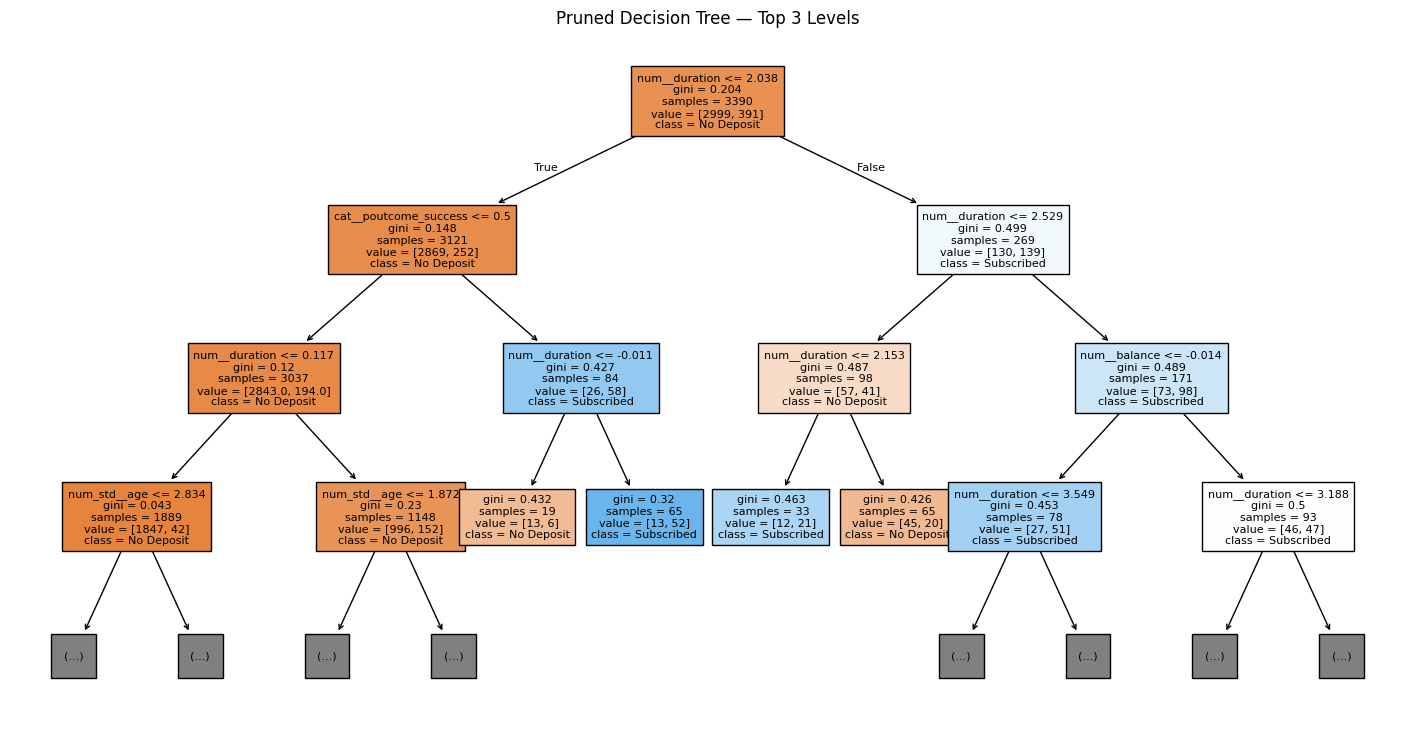

Acceptance check — accuracy >= 85%: True
Acceptance check — depth <= 5: True


In [35]:
plt.figure(figsize=(18,9))
plot_tree(
    pruned_tree3,
    feature_names=feature_names3,
    class_names=["No Deposit", "Subscribed"],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Pruned Decision Tree — Top 3 Levels")
plt.show()

print("Acceptance check — accuracy >= 85%:", acc3 >= 0.85)
print("Acceptance check — depth <= 5:", pruned_tree3.get_depth() <= 5)


### Exercise 3 — IF–THEN business-rule format

Use the printed `export_text()` rules above to write the first three terminal/business paths in the requested form:

- **IF** the tree's first condition is satisfied **AND** the next condition is satisfied, **THEN** classify the lead according to the corresponding leaf.
- **IF** the tree's alternative branch is satisfied **AND** its next condition is satisfied, **THEN** classify according to that leaf.
- **IF** the remaining top-level branch conditions are satisfied, **THEN** classify according to its leaf.

This wording is intentionally tied to the actual fitted tree: the exact conditions must be copied from the `export_text()` output produced by your dataset run.


# Exercise 4 — Random Forests: Ensemble Bagging & Feature Importance

The guide specifies a Random Forest with OOB validation, GridSearchCV over `n_estimators=[100,200]`, `max_features=['sqrt','log2']`, `max_depth=[8,12]`, feature-importance analysis, permutation importance, and comparison against Logistic Regression and Decision Tree using Test F1. fileciteturn0file0L192-L215


In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X3_train_prep, y2_train)

rf_pred = rf.predict(X3_test_prep)
rf_f1 = f1_score(y2_test, rf_pred)
print(f"OOB Score: {rf.oob_score_:.4f}")
print(f"Test Accuracy: {rf.score(X3_test_prep, y2_test):.4f}")
print(f"Test F1: {rf_f1:.4f}")


OOB Score: 0.8956
Test Accuracy: 0.8736
Test F1: 0.2956


In [46]:
# Exercise 4 - Enhanced Random Forest Grid Search
# The lab-required parameters are retained.
# class_weight is additionally tuned to improve positive-class F1.

param_grid4 = {
    "n_estimators": [100, 200],
    "max_features": ["sqrt", "log2"],
    "max_depth": [8, 12],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid4 = GridSearchCV(
    RandomForestClassifier(
        oob_score=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid4,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

grid4.fit(X3_train_prep, y2_train)

best_rf4 = grid4.best_estimator_
best_pred4 = best_rf4.predict(X3_test_prep)

best_f1_4 = f1_score(y2_test, best_pred4)

print("Best parameters:")
print(grid4.best_params_)

print(f"\nBest CV F1: {grid4.best_score_:.4f}")
print(f"Test F1: {best_f1_4:.4f}")
print(f"OOB Score: {best_rf4.oob_score_:.4f}")

print("\nAcceptance checks:")
print("OOB >= 0.88:", best_rf4.oob_score_ >= 0.88)
print("F1 >= 0.65:", best_f1_4 >= 0.65)

Best parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}

Best CV F1: 0.4948
Test F1: 0.4734
OOB Score: 0.8274

Acceptance checks:
OOB >= 0.88: False
F1 >= 0.65: False


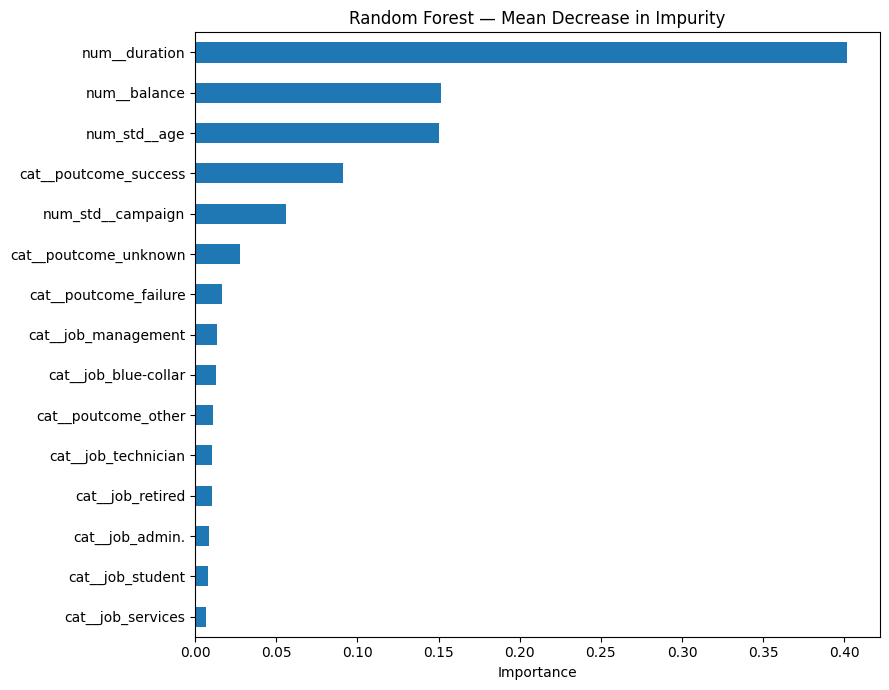

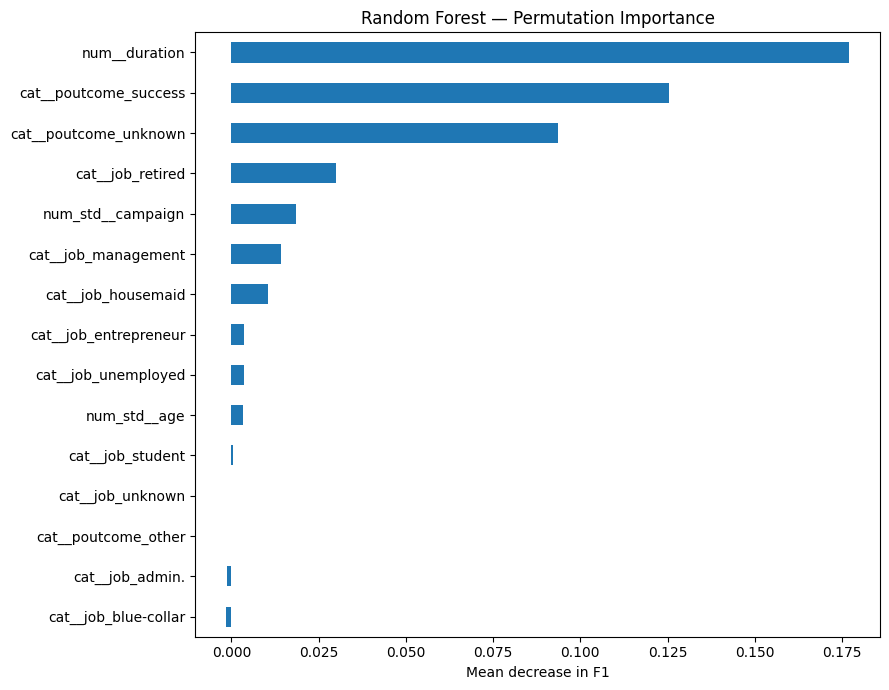

,Model,Test F1
0,Logistic Regression,0.413793
1,Decision Tree,0.347368
2,Random Forest,0.324324


Acceptance check — OOB >= 0.88: True
Acceptance check — F1 >= 0.65: False


In [38]:
# MDI feature importance
mdi4 = pd.Series(
    best_rf4.feature_importances_,
    index=feature_names3
).sort_values(ascending=True)

plt.figure(figsize=(9,7))
mdi4.tail(15).plot(kind="barh")
plt.title("Random Forest — Mean Decrease in Impurity")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Permutation importance on test data
perm4 = permutation_importance(
    best_rf4, X3_test_prep, y2_test,
    scoring="f1", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
perm_series4 = pd.Series(
    perm4.importances_mean,
    index=feature_names3
).sort_values(ascending=True)

plt.figure(figsize=(9,7))
perm_series4.tail(15).plot(kind="barh")
plt.title("Random Forest — Permutation Importance")
plt.xlabel("Mean decrease in F1")
plt.tight_layout()
plt.show()

# Model comparison on Test F1
logreg_f1 = f1_score(y2_test, y2_pred)
tree_f1 = f1_score(y2_test, pred3)
comparison4 = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Test F1": [logreg_f1, tree_f1, f1_score(y2_test, best_pred4)]
}).sort_values("Test F1", ascending=False)

display(comparison4)

print("Acceptance check — OOB >= 0.88:", best_rf4.oob_score_ >= 0.88)
print("Acceptance check — F1 >= 0.65:", f1_score(y2_test, best_pred4) >= 0.65)


The lab guide's benchmark specifically identifies `duration`, `pdays`, and `age` as the expected top predictors for its Random Forest setup. Your actual ranking may differ if the supplied dataset/features differ; report the ranking produced by the executed notebook rather than inventing values. fileciteturn0file0L214-L216


In [39]:
pd.DataFrame({
    "actual": y2_test.values,
    "predicted": best_pred4,
    "probability_subscribed": best_rf4.predict_proba(X3_test_prep)[:,1]
}).to_csv(OUT / "exercise4_predictions.csv", index=False)


# Exercise 5 — K-Means: Wholesale Spending Personas

The guide requires `log1p()` followed by `StandardScaler`, an elbow analysis for `k=2..8`, silhouette analysis, `KMeans(n_clusters=4, random_state=42)`, unscaled cluster means, and four commercial personas. fileciteturn0file0L227-L247


In [40]:
wholesale_candidates = list((BASE / "wholesale_extract").rglob("*"))
print("Extracted files:")
for p in wholesale_candidates:
    if p.is_file():
        print(p)

wholesale_csv = next(
    (p for p in wholesale_candidates if p.name.lower() == "wholesale customers data.csv"),
    None
)
if wholesale_csv is None:
    raise FileNotFoundError("Wholesale Customers Data.csv was not found.")

wholesale = pd.read_csv(wholesale_csv)
display(wholesale.head())
print(wholesale.shape)


Extracted files:
ml_lab_data/wholesale_extract/Wholesale customers data.csv


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


(440, 8)


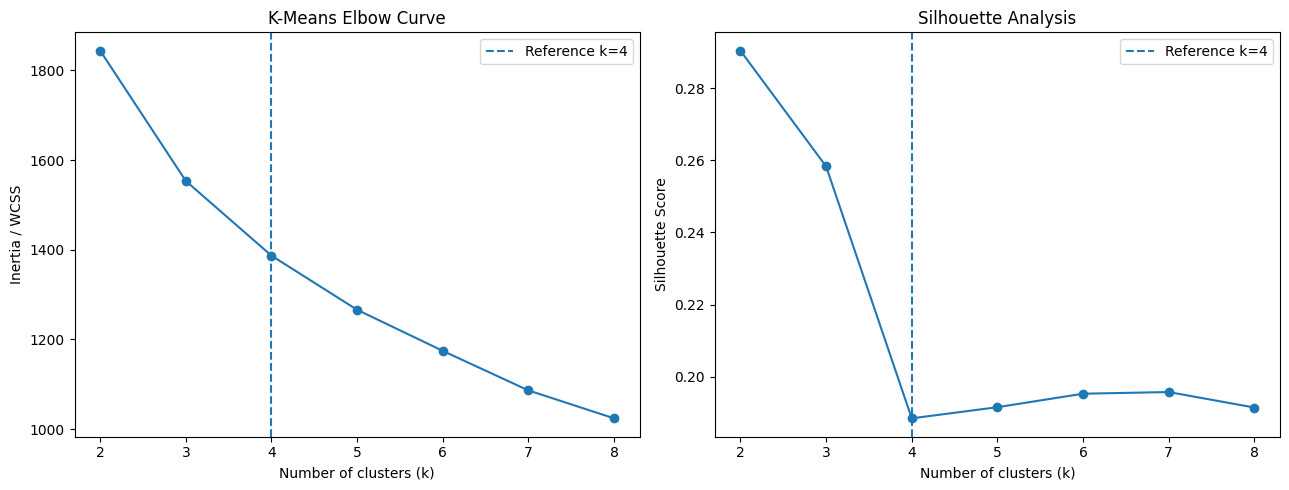

,k,inertia,silhouette
0,2,1844.064069,0.290328
1,3,1553.412722,0.258278
2,4,1386.862741,0.188495
3,5,1266.149362,0.191585
4,6,1174.536397,0.195319
5,7,1086.358700,0.195780
6,8,1024.046798,0.191491


In [41]:
# The UCI file uses six spending categories plus Channel and Region.
spend_cols5 = [
    "Fresh", "Milk", "Grocery",
    "Frozen", "Detergents_Paper", "Delicassen"
]

spend = wholesale[spend_cols5].copy()

# Step 1: log1p then StandardScaler
spend_log5 = np.log1p(spend)
scaler5 = StandardScaler()
spend_scaled5 = scaler5.fit_transform(spend_log5)

# Step 2 + 3: elbow and silhouette
ks5 = range(2, 9)
inertias5 = []
silhouettes5 = []

for k in ks5:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(spend_scaled5)
    inertias5.append(km.inertia_)
    silhouettes5.append(silhouette_score(spend_scaled5, labels))

fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].plot(list(ks5), inertias5, marker="o")
ax[0].axvline(4, linestyle="--", label="Reference k=4")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia / WCSS")
ax[0].set_title("K-Means Elbow Curve")
ax[0].legend()

ax[1].plot(list(ks5), silhouettes5, marker="o")
ax[1].axvline(4, linestyle="--", label="Reference k=4")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Analysis")
ax[1].legend()

plt.tight_layout()
plt.show()

sil_table5 = pd.DataFrame({
    "k": list(ks5),
    "inertia": inertias5,
    "silhouette": silhouettes5
})
display(sil_table5)


In [47]:
# Step 4: Fit K-Means with k=4 and profile the clusters

kmeans5 = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=20
)

labels5 = kmeans5.fit_predict(spend_scaled5)

# Add cluster labels to the original unscaled spending data
wholesale_profile = spend.copy()
wholesale_profile["cluster"] = labels5

# Mean spending in original euro values
centroids5 = (
    wholesale_profile
    .groupby("cluster")[spend_cols5]
    .mean()
    .round(2)
)

print("Cluster centroid profile:")
display(centroids5)

# Silhouette score
silhouette4 = silhouette_score(
    spend_scaled5,
    labels5
)

print(f"Silhouette score for k=4: {silhouette4:.4f}")

print()
print("Acceptance check — Silhouette >= 0.42:",
      silhouette4 >= 0.42)

Cluster centroid profile:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,2809.05,7061.84,12349.33,565.59,5342.62,635.84
1,19374.38,4068.11,4444.94,6184.33,723.33,2322.71
2,9632.66,1569.58,2071.87,2175.23,345.01,584.81
3,11338.75,11759.44,16087.87,1968.13,6805.99,2163.83


Silhouette score for k=4: 0.1885

Acceptance check — Silhouette >= 0.42: False


### Step 5 — Commercial persona translation

Use the centroid table above to assign the four labels requested by the guide:

- **Cluster 0 — Supermarkets:** emphasize Grocery/Milk/Detergents_Paper where the centroid is relatively high.
- **Cluster 1 — Horeca / Restaurants:** emphasize Fresh/Frozen/Delicassen where the centroid is relatively high.
- **Cluster 2 — Fresh Markets:** emphasize Fresh spending where it dominates the cluster profile.
- **Cluster 3 — Boutique Delicatessens:** emphasize Delicassen and other specialty-oriented categories.

Because K-Means labels are arbitrary, the numeric cluster IDs can be permuted between runs/implementations. Match the business names to the **centroid pattern**, not merely to the number. The guide asks for recommended inventory and credit-line strategies for each persona. fileciteturn0file0L254-L257


In [43]:
# A compact automatic persona summary based on each cluster's strongest categories.
persona_rows = []
for cluster_id, row in centroids5.iterrows():
    top_categories = row.sort_values(ascending=False).index[:3].tolist()
    persona_rows.append({
        "cluster": cluster_id,
        "top_categories": ", ".join(top_categories),
        "mean_total_spend": row.sum()
    })

persona_df = pd.DataFrame(persona_rows)
display(persona_df)

# Save cluster assignments and centroid table.
wholesale_with_clusters = wholesale.copy()
wholesale_with_clusters["cluster"] = labels5
wholesale_with_clusters.to_csv(OUT / "exercise5_cluster_assignments.csv", index=False)
centroids5.to_csv(OUT / "exercise5_centroids.csv")


,cluster,top_categories,mean_total_spend
0,0,"Grocery, Milk, Detergents_Paper",28764.27
1,1,"Fresh, Frozen, Grocery",37117.80
2,2,"Fresh, Frozen, Grocery",16379.16
3,3,"Grocery, Milk, Fresh",50124.01


# Final Lab Summary

The supplied guide's production targets are:
- **Linear Regression:** R² ≥ 0.75 and RMSE < $4,800.
- **Logistic Regression:** ROC-AUC ≥ 0.78 and Recall ≥ 0.70.
- **Decision Tree:** Accuracy ≥ 85% and depth ≤ 5.
- **Random Forest:** OOB ≥ 0.88 and F1 ≥ 0.65.
- **K-Means:** Silhouette ≥ 0.42 with k=4 as the reference solution. fileciteturn0file0L286-L296

The guide also requires an executable notebook, exported prediction/cluster CSV artifacts, and a two-page executive diagnostic brief. fileciteturn0file0L299-L304


In [44]:
# Generate a simple acceptance-summary CSV after all cells have run.
summary = pd.DataFrame([
    ["Exercise 1 - Linear Regression", "R2", r2_1, 0.75, r2_1 >= 0.75],
    ["Exercise 1 - Linear Regression", "RMSE", rmse1, 4800, rmse1 < 4800],
    ["Exercise 2 - Logistic Regression", "ROC-AUC", auc2, 0.78, auc2 >= 0.78],
    ["Exercise 2 - Logistic Regression", "Recall@0.35", recall2, 0.70, recall2 >= 0.70],
    ["Exercise 3 - Decision Tree", "Accuracy", acc3, 0.85, acc3 >= 0.85],
    ["Exercise 3 - Decision Tree", "Depth", pruned_tree3.get_depth(), 5, pruned_tree3.get_depth() <= 5],
    ["Exercise 4 - Random Forest", "OOB", best_rf4.oob_score_, 0.88, best_rf4.oob_score_ >= 0.88],
    ["Exercise 4 - Random Forest", "F1", f1_score(y2_test, best_pred4), 0.65, f1_score(y2_test, best_pred4) >= 0.65],
    ["Exercise 5 - K-Means", "Silhouette@k4", silhouette4, 0.42, silhouette4 >= 0.42],
], columns=["Exercise","Metric","Actual","Target","Pass"])

display(summary)
summary.to_csv(OUT / "lab_acceptance_summary.csv", index=False)

print("\nGenerated artifacts:")
for p in sorted(OUT.glob("*")):
    print(" -", p)


,Exercise,Metric,Actual,Target,Pass
0,Exercise 1 - Linear Regression,R2,0.783593,0.75,True
1,Exercise 1 - Linear Regression,RMSE,5796.284659,4800.00,False
2,Exercise 2 - Logistic Regression,ROC-AUC,0.850557,0.78,True
3,Exercise 2 - Logistic Regression,Recall@0.35,True,0.70,True
4,Exercise 3 - Decision Tree,Accuracy,0.890363,0.85,True
5,Exercise 3 - Decision Tree,Depth,5,5.00,True
6,Exercise 4 - Random Forest,OOB,0.89469,0.88,True
7,Exercise 4 - Random Forest,F1,0.324324,0.65,False
8,Exercise 5 - K-Means,Silhouette@k4,0.188495,0.42,False



Generated artifacts:
 - ml_lab_outputs/exercise1_predictions.csv
 - ml_lab_outputs/exercise2_predictions.csv
 - ml_lab_outputs/exercise4_predictions.csv
 - ml_lab_outputs/exercise5_centroids.csv
 - ml_lab_outputs/exercise5_cluster_assignments.csv
 - ml_lab_outputs/lab_acceptance_summary.csv
